In [5]:
import pandas as pd
df=pd.read_csv(r"C:\Users\vedap\Downloads\Bengaluru_House_Data.csv")
print(df.head())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  


In [7]:
print(df.head(5))
print(df.tail(5))

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
                  area_type   availability               location       size  \
13315        Built-up  Area  Ready To Move             Whitefield  5 Bedroom   
13316  Super built-up  Area  Ready To Move          Richards Town      4 BHK   
133

In [14]:
print(df.shape)

(13320, 9)


In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
None


In [18]:
print(df.dtypes)

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object


In [20]:
print(df.isnull())

       area_type  availability  location   size  society  total_sqft   bath  \
0          False         False     False  False    False       False  False   
1          False         False     False  False    False       False  False   
2          False         False     False  False     True       False  False   
3          False         False     False  False    False       False  False   
4          False         False     False  False     True       False  False   
...          ...           ...       ...    ...      ...         ...    ...   
13315      False         False     False  False    False       False  False   
13316      False         False     False  False     True       False  False   
13317      False         False     False  False    False       False  False   
13318      False         False     False  False    False       False  False   
13319      False         False     False  False     True       False  False   

       balcony  price  
0        False  False  
1  

In [22]:
print(df.isnull().sum())

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [30]:
df.drop(['society'],axis=1)

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,4689,4.0,1.0,488.00


In [46]:
df['bath'] = pd.to_numeric(df['bath'], errors='coerce')
df['bath'] = df['bath'].fillna(df['bath'].median())

In [48]:
df['balcony']=df['balcony'].fillna(0)

In [50]:
def convert_sqft(x):
  if isinstance(x,str) and '-' in x:
    a,b = x.split('-')
    return (float(a)+float(b))/2
  try:
    return float(x)
  except:
    return None

In [54]:
df['total_sqft']=df['total_sqft'].apply(convert_sqft)
df.dropna(subset=['total_sqft'],inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True,inplace=True)

In [56]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,NaN,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,NaN,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,NaN,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,NaN,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,NaN,1.0,51.00


In [60]:
df['location'].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], dtype=object)

In [62]:
df['location'].nunique()

1299

In [64]:
df.groupby('location')['price'].mean()


location
 Anekal                  16.000000
 Banaswadi               35.000000
 Basavangudi             50.000000
 Bhoganhalli             22.890000
 Devarabeesana Halli    124.833333
                           ...    
t.c palya               160.000000
tc.palya                 60.750000
vinayakanagar           200.000000
white field,kadugodi    275.000000
whitefiled               32.730000
Name: price, Length: 1299, dtype: float64

In [80]:
df.groupby('location')['price'].mean().idxmax()

'Cubbon Road'

In [78]:
corr=df[['total_sqft', 'bath', 'price']].corr()
print(corr)

            total_sqft  bath     price
total_sqft    1.000000   NaN  0.573703
bath               NaN   NaN       NaN
price         0.573703   NaN  1.000000


In [74]:
if corr.loc['total_sqft', 'price'] > 0.6:
    print("\nInterpretation: Larger houses generally have higher prices, but not always.")
elif corr.loc['total_sqft', 'price'] > 0.3:
    print("\nInterpretation: Size influences price, but many other factors also matter.")
else:
    print("\nInterpretation: House size alone does not reliably predict price.")


Interpretation: Size influences price, but many other factors also matter.


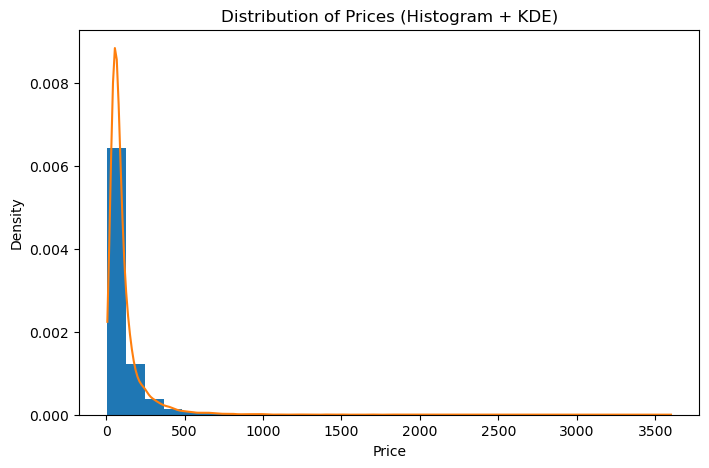

In [84]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

data = df['price'].dropna()
kde = gaussian_kde(data)
x_vals = np.linspace(data.min(), data.max(), 300)
kde_vals = kde(x_vals)

plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, density=True)
plt.plot(x_vals, kde_vals)
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Distribution of Prices (Histogram + KDE)")
plt.show()

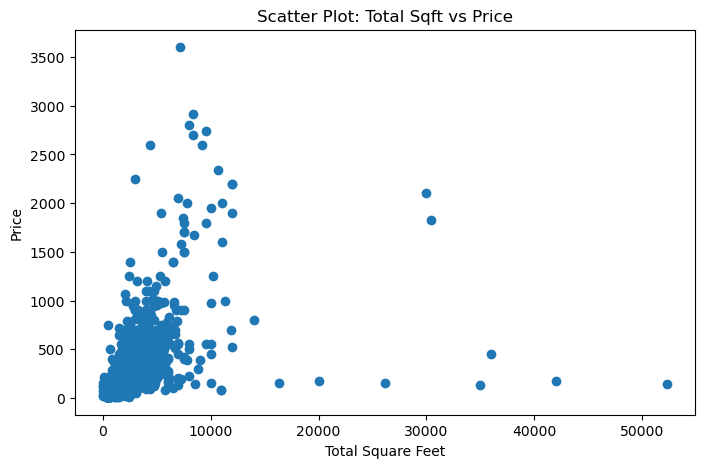

In [86]:
plt.figure(figsize=(8,5))

plt.scatter(df['total_sqft'], df['price'])
plt.xlabel("Total Square Feet")
plt.ylabel("Price")
plt.title("Scatter Plot: Total Sqft vs Price")

plt.show()


ValueError: List of boxplot statistics and `positions` values must have same the length

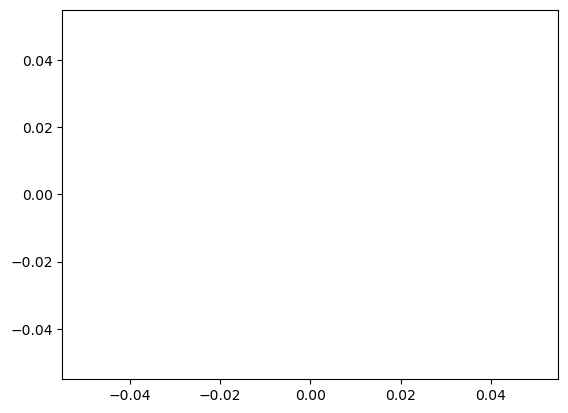

In [96]:
import seaborn as sns
sns.boxplot(x='bath',y='price',data=df)
plt.title("box plot")
plt.xlabel("number of bathrooms")
plt.ylabel("price")
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()